**Table of contents**<a id='toc0_'></a>    
- 1. [Práctica 1 - Ejercicio 1 - Enunciado](#toc1_)    
- 2. [Comentarios previos](#toc2_)    
- 3. [Generación de datos](#toc3_)    
  - 3.1. [Funciones $f_1, f_2, f_3$](#toc3_1_)    
  - 3.2. [Ruido y datasets](#toc3_2_)    
  - 3.3. [Dataloaders](#toc3_3_)    
- 4. [Modelo y entrenamiento](#toc4_)    
  - 4.1. [Hiperparámetros](#toc4_1_)    
  - 4.2. [Entrenamiento](#toc4_2_)    
- 5. [Test](#toc5_)    
- 6. [Referencias](#toc6_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Práctica 1 - Ejercicio 1 - Enunciado](#toc0_)

Asignatura: Programación para la Inteligencia Artificial

Alumno: Javier Márquez Ruiz.

En esta práctica se tienen que realizar dos ejercicios en dos cuadernos de Jupyter separados. Este es el primer ejercicio y el segundo se proporcionará durante la siguiente sesión de prácticas.

El primer ejercicio tiene como objetivo entrenar un modelo neuronal de capas lineales con PyTorch que ajuste simultáneamente las funciones siguientes:

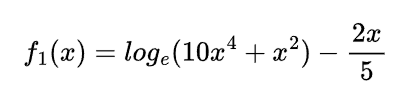

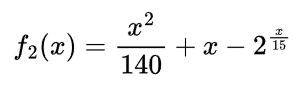

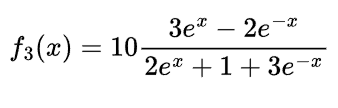

El modelo debe tener una entrada $(x)$, tres salidas $f_1(x), f_2(x)$ y $f_3(x)$ y debe ser capaz de generalizar en el rango $x \in [-120,120]$. Los datos para el entrenamiento se deben generar usando PyTorch con un error de media 0 y desviación típica 5 siguiendo una estrategia similar a la vista en clase. Para gestion de los datos durante el entrenamiento es requisito obligatorio usar *DataLoaders*.

Como resultado se espera este mismo cuaderno editado que incluya el código y los experimentos más relevantes realizados para alcanzar la mejor solución encontrada. Como resultado de esos experimentos, siguiendo lo visto en clase, se espera la visualización de las funciones aprendidas por el modelo y un breve análisis.

En los experimentos es obligatorio usar, además del subconjunto de entrenamiento, un subconjunto de validación durante el entrenamiento y un subconjunto de test que se usará solo después del entrenamiento para obtener una medida de error final. Esa medida del error final se debe realizar usando la media del error absoluto. Tanto el subconjunto de validación como el subconjunto de test deben contar con 500 ejemplos. El tamaño del conjunto de entrenamiento queda a criterio del estudiante.

El cuaderno entregado debe llamarse ApellidosNombrePractica1Ejercicio1.ipynb


# 2. <a id='toc2_'></a>[Comentarios previos](#toc0_)

Una entrada y tres salidas $\Rightarrow$ crear un dataset con las columnas `x`, `y_1`, `y_2`, `y_3`. La red deberá tener 3 neuronas en la última capa.

El problema es de regresión múltiple.

Algunos detalles sobre **la generación de datos**:
- En la primera función hay que tener cuidado con el logaritmo de $0$.
- La segunda función podría dar problemas por tener un exponente demasiado grande. Pero como $120/15 = 8$, estaría entre $2^{-8}$ o $2^{8}$, así que no creo que sea un problema.
- El denominador de la tercera función no puede valer $0$ para $x \in \R$. El denominador será mayor que $0$ así que no me preocupo.
- Pero **sí es un problema $e^{-120}$ o $e^{120}$**.
  - En todo caso es fácil ver que $\lim_{x \to \infty} = 10 \cdot 3/2 = 15$, y para $\lim_{x \to \infty} = 10 \cdot -2/3 = -20 / 3$.
  - Si $x$ es demasiado grande podría devolver $15$ sin más cálculos, y si demasiado pequeña por $-20/3 = 6.6666666...$.

Finalmente he decidido generar los datos sin tratar estos casos, para tener datos imperfectos.

In [1]:
import torch
import matplotlib.pyplot as plt
import sys
import numpy as np
from tqdm import tqdm

In [2]:
cuda_avaliable = torch.cuda.is_available()

print(f"Versión de Python: {sys.version}")
print(f"Versión de PyTorch: {torch.__version__}")
print(f"Disponibilidad de CUDA: {cuda_avaliable}")
print(f"Versión de CUDA: {torch.version.cuda if torch.cuda.is_available() else None}")

Versión de Python: 3.12.3 (main, Aug 14 2025, 17:47:21) [GCC 13.3.0]
Versión de PyTorch: 2.8.0+cu128
Disponibilidad de CUDA: False
Versión de CUDA: None


# 3. <a id='toc3_'></a>[Generación de datos](#toc0_)

Basándome los apuntes de otra asignatura, Desarrollo para Software Crítico:
- _Training set_ $\approx 70\%$, para que el modelo aprenda.
- _Validation set_ $\approx 15\%$, utilizado para ajustar parámetros, capas, y otras decisiones. Se utiliza mientras se entrena el modelo.
- _Test dataset_ $\approx 15\%$ para evaluar el modelo.

Por tanto, $1000$ ejemplos serán el $30\%$ y el conjunto de entrenamiento constará de $3500$ ejemplos (por redondear).

Entiendo también que los datos del eje $x$ deben ser aleatorios y no uniformemente distribuidos, intentando que se asemejen a "datos imperfectos".

## 3.1. <a id='toc3_1_'></a>[Funciones $f_1, f_2, f_3$](#toc0_)

In [3]:
def f_1(x:torch.DoubleTensor) -> torch.DoubleTensor:
    return torch.log(10 * x**4 + x**2) - (2*x / 5) 

def f_2(x:torch.DoubleTensor) -> torch.DoubleTensor:
    return (x**2 / 140) + x - (2**(x/15))

def f_3(x:torch.DoubleTensor, x_threshold=10) -> torch.DoubleTensor:
    """ 
    Threshold debe ser positivo. 
    A parte de implementar f_3, devuelve 15 o -20/3 directamente para valores 
    de x demasiado grandes o pequeños (según el threshold). """
    y_3 = 10 * ((3*torch.e**x - 2*torch.e**(-x)) / (2*torch.e**x + 1 + 3*torch.e**(-x))) # Aquí pasan las cosas raras
    # torch.where(condition, if_true, if_false). Es como ()? ... : ... para tensores.
    y_3 = torch.where(x < -x_threshold, torch.tensor(-20/3), y_3) # Aquí se soluciona. 
    y_3 = torch.where(x > x_threshold, torch.tensor(15), y_3)
    return y_3

# x = torch.linspace(-120, 120, steps=3500)
x = 240 * torch.rand(3500) - 120 # Datos desde -120 hasta 120. Genero de 0 a 240 y luego desplazo a la izquierda
x, _ = torch.sort(x)

y_1 = f_1(x)
y_2 = f_2(x)
y_3 = f_3(x)

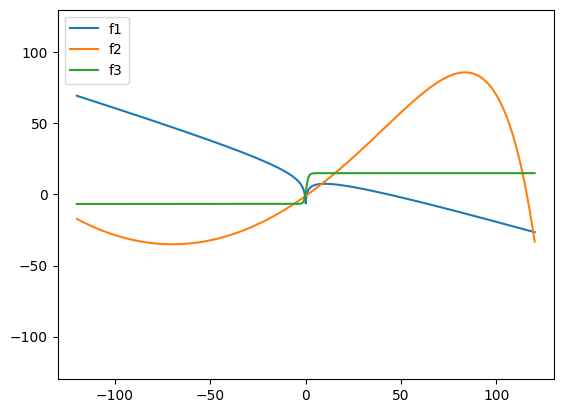

x min, max:  -119.99928283691406 119.99107360839844
y_1:  -26.54416847229004 69.4522476196289
y_2:  -35.039485931396484 85.90666198730469
y_3:  -6.666666507720947 15.0


In [4]:
plt.plot(x, y_1, label="f1")
plt.plot(x, y_2, label="f2")
plt.plot(x, y_3, label="f3")
plt.xlim(-130, 130)
plt.ylim(-130, 130)
plt.legend()
plt.show()
print("x min, max: ", x.min().item(), x.max().item())
print("y_1: ", y_1.min().item(), y_1.max().item())
print("y_2: ", y_2.min().item(), y_2.max().item())
print("y_3: ", y_3.min().item(), y_3.max().item()) # -inf :C

In [5]:
print(x)
f_3(x)

tensor([-119.9993, -119.8963, -119.8561,  ...,  119.8095,  119.8138,
         119.9911])


tensor([-6.6667, -6.6667, -6.6667,  ..., 15.0000, 15.0000, 15.0000])

De momento no me convence mucho utilizar los valores escalados.

## 3.2. <a id='toc3_2_'></a>[Ruido y datasets](#toc0_)

Para cada punto "ruidoso" generado, utiliza cada valor de $y\_x$ como la media, que sería como sumar el valor $y_1$ más el ruido (si es que he comprendido bien las propiedades de la distribución normal). Comparando (a ojímetro) con el método del cuaderno "Aprendizaje en PyTorch I", el resultado parece igual.

La transparencia (`alpha`) ayuda a ver la densidad de los puntos cuando hay demasiados cerca.

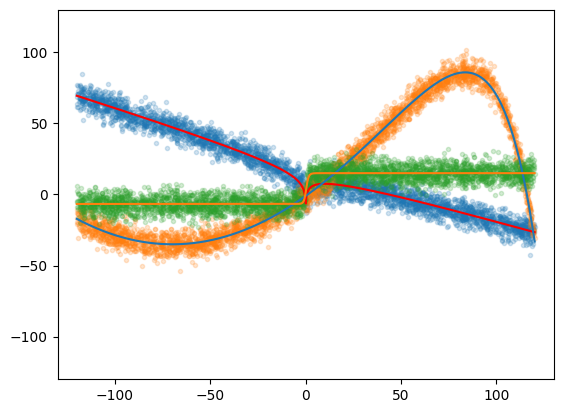

In [6]:
# y_1_noisy = torch.normal(y_1, 5*torch.ones_like(y_1))
noise_y = torch.normal(torch.zeros_like(y_1), 5*torch.ones_like(y_1)) # Para comparar
y_1_noisy = y_1 + noise_y 
y_2_noisy = torch.normal(y_2, 5*torch.ones_like(y_2))
y_3_noisy = torch.normal(y_3, 5*torch.ones_like(y_3))

plt.plot(x, y_1, c='r') # Ha dado la casualidad que los colores con este parámetro se quedan decentes
plt.plot(x, y_2)
plt.plot(x, y_3)
plt.scatter(x, y_1_noisy, marker='.', alpha=0.2)
plt.scatter(x, y_2_noisy, marker='.', alpha=0.2)
plt.scatter(x, y_3_noisy, marker='.', alpha=0.2)
plt.xlim(-130, 130)
plt.ylim(-130, 130)
plt.show()

In [7]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [8]:
# Parece que con esto el tensor de las dimensiones que quiero: "3500 filas y 3 columnas" (y si no es así, me lo imagino así)
# Esto es simplemente para comprobarlo antes de la siguiente celda. Esta celda no debería existir
y = torch.stack([y_1, y_2, y_3], dim=1)
print(y.shape)
print(y[1])
print(y[1,])
print(y[1, :]) # El dataloader indexará como quiero

torch.Size([3500, 3])
tensor([ 69.4076, -17.2208,  -6.6667])
tensor([ 69.4076, -17.2208,  -6.6667])
tensor([ 69.4076, -17.2208,  -6.6667])


**Inciso**
Recordar esa dimensión extra necesaria:

```python
x.shape = torch.Size([3500]) # Tensor unidimensional. Cada valor es un escalar. No compatible con capas lineales
torch.unsqueeze(x,1).shape = torch.Size([3500, 1]) # Tensor "de 3500 filas y 1 columna". Tensor BIDIMENSIONAL.
```

In [9]:
class PointsDataset(Dataset):
    def __init__(self, x:torch.DoubleTensor, y_1:torch.DoubleTensor, y_2:torch.DoubleTensor, y_3:torch.DoubleTensor):
        if (len(x) == len(y_1) and len(y_1) == len(y_2) and len(y_2) == len(y_3)):
            self.x = torch.unsqueeze(x,1) # !!!!!!!!! Notebook "Modelos Neuronales III" => "dimensión ficticia" y batches
            self.y_1 = y_1
            self.y_2 = y_2
            self.y_3 = y_3
        else:
            raise ValueError("Tensors must have same shape")
        self.y = torch.stack([y_1, y_2, y_3], dim=1)

    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, index):
        return self.x[index], self.y[index]
    
    def subdataset(self, mask):
        """Devuelve un subdataset a partir de la mask"""
        return PointsDataset(self.x.squeeze(1)[mask], self.y_1[mask], self.y_2[mask], self.y_3[mask])

In [10]:
points_dataset = PointsDataset(x, y_1, y_2, y_3)

## 3.3. <a id='toc3_3_'></a>[Dataloaders](#toc0_)

Antes de crear los dataloaders, voy a comprobar si hay datos de tipo `nan`, `inf` o `-inf` que convenga tratar de alguna forma. Normalmente supongo que se haría un análisis más en detalle de los datos, pero ahora voy a preocuparme de que no explote todo.

Al parecer, al igual que en Numpy, los tensores se pueden usar como _masks_.

In [11]:
x_dataset, y_dataset = points_dataset[:]

print(x_dataset[torch.isinf(x_dataset)]) # OK
print(x_dataset[torch.isnan(x_dataset)]) # OK
print(y_dataset[torch.isinf(y_dataset)]) # Habemus problemas
print(y_dataset[torch.isnan(y_dataset)]) # OK
mask_dataset = ~torch.isinf(y_dataset) # No funciona broadcast con `not`, ya que no sabe si "es uno a uno o todos".
mask_dataset = torch.all(mask_dataset, dim=1) # AND lógico "fila a fila" (sobre la dim=1; dim=0 "son las columnas")
print(mask_dataset.shape)
points_dataset = points_dataset.subdataset(mask_dataset)
x_dataset.shape

tensor([])
tensor([])
tensor([])
tensor([])
torch.Size([3500])


torch.Size([3500, 1])

In [12]:
x_dataset, y_dataset = points_dataset[:, :]

print(x_dataset[torch.isinf(x_dataset)]) # OK
print(x_dataset[torch.isnan(x_dataset)]) # OK
print(y_dataset[torch.isinf(y_dataset)]) # OK
print(y_dataset[torch.isnan(y_dataset)]) # OK
print(x_dataset.shape) # Parece estar en orden
print(y_dataset.shape) 

tensor([])
tensor([])
tensor([])
tensor([])
torch.Size([3500, 1])
torch.Size([3500, 3])


Ya "está arreglado" `points_dataset`

In [13]:
from torch.utils.data import random_split

# dataloader = DataLoader(points_dataset, batch_size=64, shuffle=True)
# `lengths` son proporciones, no longitudes absolutas
train_dataset, val_dataset, test_dataset = random_split(points_dataset, lengths=[0.7, 0.15, 0.15])

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [14]:
print("Original dataset len: ", len(points_dataset))
print("Train dataset len: ", len(train_dataset))
print("Validation dataset len: ", len(val_dataset))
print("Test dataset len: ", len(test_dataset))
print("Sum of the splits: ", len(train_dataset) + len(val_dataset) + len(test_dataset))

print("======")

dataloader = DataLoader(points_dataset, batch_size=64, shuffle=True)
for i, batch in enumerate(dataloader, 3490): # Para no iterar tantas veces: solo 10
  print(f"Iteración {i}")
  print(f"Tipo de batch: {type(batch)}")
  print(f"Longitud de batch: {len(batch)}")
  print(f"Tamaño de batch[0]: {batch[0].shape}")
  print(f"Tamaño de batch[1]: {batch[1].shape}")

Original dataset len:  3500
Train dataset len:  2450
Validation dataset len:  525
Test dataset len:  525
Sum of the splits:  3500
Iteración 3490
Tipo de batch: <class 'list'>
Longitud de batch: 2
Tamaño de batch[0]: torch.Size([64, 1])
Tamaño de batch[1]: torch.Size([64, 3])
Iteración 3491
Tipo de batch: <class 'list'>
Longitud de batch: 2
Tamaño de batch[0]: torch.Size([64, 1])
Tamaño de batch[1]: torch.Size([64, 3])
Iteración 3492
Tipo de batch: <class 'list'>
Longitud de batch: 2
Tamaño de batch[0]: torch.Size([64, 1])
Tamaño de batch[1]: torch.Size([64, 3])
Iteración 3493
Tipo de batch: <class 'list'>
Longitud de batch: 2
Tamaño de batch[0]: torch.Size([64, 1])
Tamaño de batch[1]: torch.Size([64, 3])
Iteración 3494
Tipo de batch: <class 'list'>
Longitud de batch: 2
Tamaño de batch[0]: torch.Size([64, 1])
Tamaño de batch[1]: torch.Size([64, 3])
Iteración 3495
Tipo de batch: <class 'list'>
Longitud de batch: 2
Tamaño de batch[0]: torch.Size([64, 1])
Tamaño de batch[1]: torch.Size([64

In [15]:
points_dataset[0]

(tensor([-119.9993]), tensor([ 69.4522, -17.1473,  -6.6667]))

# 4. <a id='toc4_'></a>[Modelo y entrenamiento](#toc0_)

## 4.1. <a id='toc4_1_'></a>[Hiperparámetros](#toc0_)

In [16]:
batch_size = 64
learning_rate = 1e-4
epochs = 20000
# epochs = 200 # TODO: CAMBIAR. PEQUEÑO PARA PROBAR EL CÓDIGO
loss_fn = torch.nn.MSELoss()

El modelo tiene que tener un _input_ y 3 _outputs_.

In [17]:
# torch.nn.modules.activation.LeakyReLU
model = torch.nn.Sequential(
    torch.nn.Linear(1,16),
    torch.nn.Linear(16,3)
)

optimizer = torch.optim.SGD

## 4.2. <a id='toc4_2_'></a>[Entrenamiento](#toc0_)

In [18]:
def learning_loop_with_val(train_dataloader, val_dataloader, model, epochs, loss_fn, learning_rate, optimizer):
  train_loss_list = []
  val_loss_list = []
  opt = optimizer(
    model.parameters(),
    lr=learning_rate
  )

  for epoch in tqdm(range(epochs), desc="epoch:"):
    train_step_loss_list = []
    for x_train_true, y_train_true in train_dataloader:
      y_pred = model(x_train_true)                        # Forward
      opt.zero_grad()
      loss = loss_fn(y_pred, y_train_true)
      if torch.isnan(loss):                     # Borrar
        print("NaN detected in training loss!") # Borrar
      loss.backward()                                     # Backward
      train_step_loss_list.append(loss.clone().detach())
      opt.step()
    train_loss_list.append(torch.tensor(train_step_loss_list).mean())

    # Realizaremos una época de validación cada 10 pasos de entrenamiento para
    # minimizar los cálculos que no son estrictamente necesarios.
    if epoch % 10 == 0:
      val_step_loss_list = []
      with torch.no_grad():
        for x_val_true, y_val_true in val_dataloader:
          y_val_pred = model(x_val_true)
          loss_val = loss_fn(y_val_pred, y_val_true)
          val_step_loss_list.append(loss_val)
        val_loss_list.append(torch.tensor(val_step_loss_list).mean())

  return model, train_loss_list, val_loss_list

In [19]:
model, train_loss_list, val_loss_list = learning_loop_with_val(train_dataloader,
                                                               val_dataloader,
                                                               model,
                                                               epochs,
                                                               loss_fn,
                                                               learning_rate,
                                                               optimizer)

epoch::  17%|█▋        | 3498/20000 [00:44<03:31, 78.12it/s]


KeyboardInterrupt: 

In [ ]:
val_loss_list

[tensor(335.0161),
 tensor(316.9456),
 tensor(284.6849),
 tensor(227.1795),
 tensor(229.3907),
 tensor(203.8175),
 tensor(248.0352),
 tensor(205.0027),
 tensor(234.1480),
 tensor(197.0621),
 tensor(209.2193),
 tensor(192.6282),
 tensor(188.8128),
 tensor(222.4611),
 tensor(232.8024),
 tensor(189.0845),
 tensor(261.3894),
 tensor(198.4175),
 tensor(215.5368),
 tensor(191.9175)]

# 5. <a id='toc5_'></a>[Test](#toc0_)

# 6. <a id='toc6_'></a>[Referencias](#toc0_)

(Es para mí más que nada, no sé citar ni cosas de esas)
- [Datasets & Dataloaders](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html)
  - The __getitem__ function loads and returns a sample from the dataset at the given index idx.
  - [Split dataset - `random_split`](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.random_split)
- [Unsqueeze](https://docs.pytorch.org/docs/stable/generated/torch.unsqueeze.html)
- Deep Learning with PyTorch
  - 3 It starts with a tensor
> PyTorch uses a trailing underscore to indicate that a function operates in place on a tensor (for example, Tensor.sqrt_).

_Y ChatGPT_.